# Target Exploration

In this notebook we explore all the possible targets that we are trying to predict

## Library import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations
import scipy.stats as ss
from scipy.stats import pointbiserialr, chi2_contingency
import sys
import os

PROJECT_DIR = os.path.dirname(os.getcwd())
sys.path.append(PROJECT_DIR)

# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

We load the preprocessed feature matrix (`X_features.parquet`, 64 predictors) and the target matrix (`y_targets.parquet`, 9 binary clinical endpoints recorded within 335 days of follow-up).

In [2]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/X_features.parquet'))
y_df = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/y_targets.parquet'))

target_features = y_df

# Target Distribution Analysis

We plot the distribution of each target to get a first look at class balance. As expected for clinical adverse events, all nine endpoints are dominated by the negative (no-event) class.

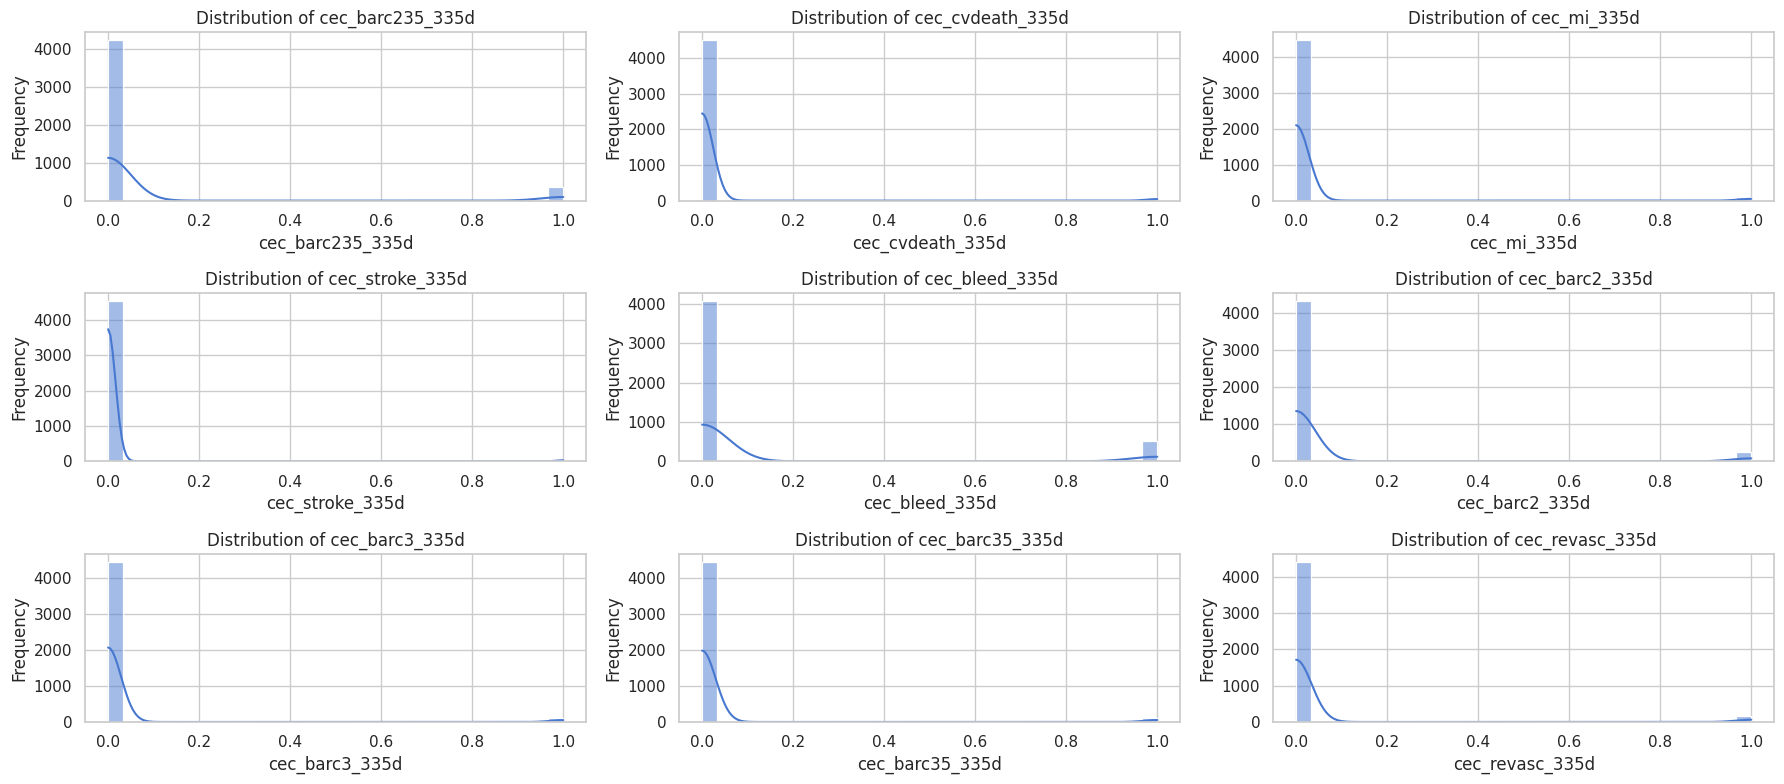

In [3]:
fig, axes = plt.subplots(nrows=len(target_features.columns)//3 + len(target_features.columns) % 3, ncols=3, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(target_features.columns):
    sns.histplot(target_features[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()


## Target Value Count

The table below reports, for each target, the number and proportion of patients in each class (0 = no event, 1 = event).

In [4]:
Val_counts_df = pd.concat([
    target_features[col]
        .value_counts()
        .reset_index()
        .set_axis(['value', 'count'], axis=1)
        .assign(
            proportion=lambda d: d['count'] / d['count'].sum(),
            target=col
        )
    for col in target_features.columns
], ignore_index=True)[['target', 'value', 'count', 'proportion']]

display(Val_counts_df)

,target,value,count,proportion
0,cec_barc235_335d,0,4220,0.92
1,cec_barc235_335d,1,359,0.08
2,cec_cvdeath_335d,0,4498,0.98
3,cec_cvdeath_335d,1,81,0.02
4,cec_mi_335d,0,4470,0.98
5,cec_mi_335d,1,109,0.02
6,cec_stroke_335d,0,4544,0.99
7,cec_stroke_335d,1,35,0.01
8,cec_bleed_335d,0,4073,0.89
9,cec_bleed_335d,1,506,0.11


To make the class imbalance more concrete, the table below ranks the targets by the absolute number of positive events — for the rarest endpoints (stroke, CV death, MI) there are fewer than 110 positive cases in the entire cohort.

In [5]:
n_total = len(target_features)

events_summary = (
    Val_counts_df[Val_counts_df['value'] == 1]
    .sort_values('count')
    .reset_index(drop=True)
    .rename(columns={'count': 'n_events', 'proportion': 'event_rate'})
    [['target', 'n_events', 'event_rate']]
)

print(f"Total patients: {n_total}")
display(events_summary)

Total patients: 4579


,target,n_events,event_rate
0,cec_stroke_335d,35,0.01
1,cec_cvdeath_335d,81,0.02
2,cec_mi_335d,109,0.02
3,cec_barc3_335d,112,0.02
4,cec_barc35_335d,122,0.03
5,cec_revasc_335d,162,0.04
6,cec_barc2_335d,254,0.06
7,cec_barc235_335d,359,0.08
8,cec_bleed_335d,506,0.11


# Target Hierarchy & Co-occurrence Analysis

Several of the bleeding endpoints are clinically nested within each other (BARC 3 ⊆ BARC 3-5 ⊆ BARC 2-3-5 ⊆ overall bleeding composite), and the four ischemic endpoints (CV death, MI, stroke, revascularization) can co-occur in the same patient. Understanding these relationships matters before choosing which target(s) to model, since some targets are strict subsets of others and therefore carry largely redundant information.

**Bleeding hierarchy.** We verify the nested subset relationships between the BARC-based bleeding endpoints and print the number of events at each level, from the broadest composite down to the most severe.

In [6]:
bleeding_targets = ['cec_barc3_335d', 'cec_barc35_335d', 'cec_barc2_335d', 'cec_barc235_335d', 'cec_bleed_335d']

barc3 = target_features['cec_barc3_335d'] == 1
barc35 = target_features['cec_barc35_335d'] == 1
barc2 = target_features['cec_barc2_335d'] == 1
barc235 = target_features['cec_barc235_335d'] == 1
bleed = target_features['cec_bleed_335d'] == 1

print("Subset relationships among bleeding endpoints:")
print(f"  BARC3 subset of BARC3-5      : {(barc3 <= barc35).all()}")
print(f"  BARC2 subset of BARC2-3-5    : {(barc2 <= barc235).all()}")
print(f"  BARC3-5 subset of BARC2-3-5  : {(barc35 <= barc235).all()}")
print(f"  BARC2-3-5 subset of Bleed    : {(barc235 <= bleed).all()}")
print(f"  BARC2-3-5 == BARC2 OR BARC3-5: {(barc235 == (barc2 | barc35)).all()}")

print("\nEvent counts (broadest -> narrowest):")
for col in ['cec_bleed_335d', 'cec_barc235_335d', 'cec_barc35_335d', 'cec_barc2_335d', 'cec_barc3_335d']:
    n = target_features[col].sum()
    print(f"  {col:<20s}: {n:4d} events ({n/n_total:.1%})")

Subset relationships among bleeding endpoints:
  BARC3 subset of BARC3-5      : True
  BARC2 subset of BARC2-3-5    : True
  BARC3-5 subset of BARC2-3-5  : True
  BARC2-3-5 subset of Bleed    : True
  BARC2-3-5 == BARC2 OR BARC3-5: True

Event counts (broadest -> narrowest):
  cec_bleed_335d      :  506 events (11.1%)
  cec_barc235_335d    :  359 events (7.8%)
  cec_barc35_335d     :  122 events (2.7%)
  cec_barc2_335d      :  254 events (5.5%)
  cec_barc3_335d      :  112 events (2.4%)


The chart below visualizes this hierarchy as a funnel, from the overall bleeding composite down to BARC 3 bleeds.

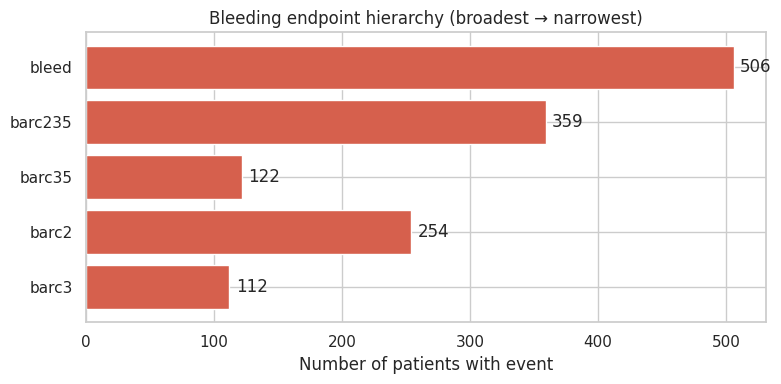

In [7]:
order = ['cec_bleed_335d', 'cec_barc235_335d', 'cec_barc35_335d', 'cec_barc2_335d', 'cec_barc3_335d']
counts = [int(target_features[c].sum()) for c in order]
labels = [c.replace('cec_', '').replace('_335d', '') for c in order]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(labels, counts, color='#d6604d')
for i, c in enumerate(counts):
    ax.text(c + 5, i, str(c), va='center')
ax.invert_yaxis()
ax.set_xlabel('Number of patients with event')
ax.set_title('Bleeding endpoint hierarchy (broadest → narrowest)')
plt.tight_layout()
plt.show()

**Ischemic endpoints.** Unlike the bleeding endpoints, the ischemic outcomes (CV death, MI, stroke, revascularization) are not nested — they can occur independently or together. The heatmap below shows how often each pair co-occurs in the same patient.

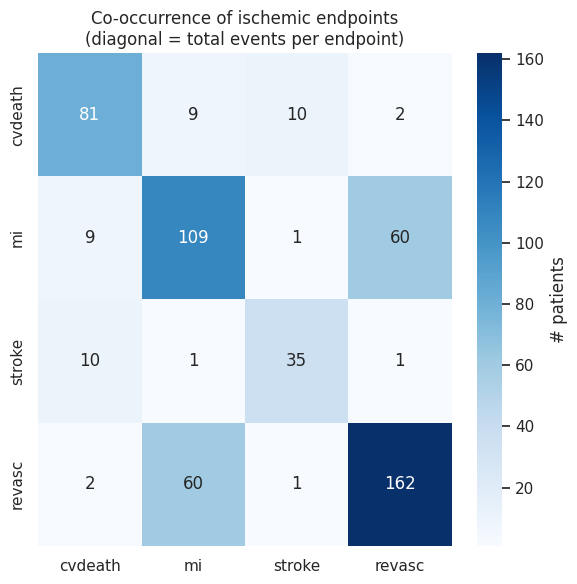

Patients with >=1 ischemic event: 307 (6.7%)
Patients with >=2 simultaneous ischemic events: 77


In [8]:
ischemic_targets = ['cec_cvdeath_335d', 'cec_mi_335d', 'cec_stroke_335d', 'cec_revasc_335d']
ischemic_labels = [c.replace('cec_', '').replace('_335d', '') for c in ischemic_targets]

cooc = pd.DataFrame(
    [[int(((target_features[a] == 1) & (target_features[b] == 1)).sum()) for b in ischemic_targets] for a in ischemic_targets],
    index=ischemic_labels, columns=ischemic_labels
)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': '# patients'})
ax.set_title('Co-occurrence of ischemic endpoints\n(diagonal = total events per endpoint)')
plt.tight_layout()
plt.show()

any_ischemic = (target_features[ischemic_targets] == 1).any(axis=1)
multi_ischemic = (target_features[ischemic_targets] == 1).sum(axis=1) > 1
print(f"Patients with >=1 ischemic event: {any_ischemic.sum()} ({any_ischemic.mean():.1%})")
print(f"Patients with >=2 simultaneous ischemic events: {multi_ischemic.sum()}")

**Bleeding vs. ischemic events.** Finally, we check how much overlap exists between the bleeding and ischemic event groups, and how many patients experience neither.

In [9]:
n_bleed_only = (bleed & ~any_ischemic).sum()
n_ischemic_only = (~bleed & any_ischemic).sum()
n_both = (bleed & any_ischemic).sum()
n_neither = n_total - n_bleed_only - n_ischemic_only - n_both

overlap_df = pd.DataFrame({
    'group': ['Bleeding only', 'Ischemic only', 'Both', 'Neither'],
    'n_patients': [n_bleed_only, n_ischemic_only, n_both, n_neither],
})
overlap_df['proportion'] = overlap_df['n_patients'] / n_total
display(overlap_df)

,group,n_patients,proportion
0,Bleeding only,432,0.09
1,Ischemic only,233,0.05
2,Both,74,0.02
3,Neither,3840,0.84


**Takeaway:** The five BARC-based bleeding targets form a strict hierarchy — `cec_bleed_335d` ⊇ `cec_barc235_335d` = `cec_barc2_335d` ∪ `cec_barc35_335d` ⊇ `cec_barc35_335d` ⊇ `cec_barc3_335d` — so they are not independent prediction targets; modeling several of them separately means predicting heavily overlapping (nested) labels. The four ischemic endpoints overlap much less, with the largest co-occurrence between MI and revascularization. Only a small fraction of patients experience both a bleeding and an ischemic event, suggesting these reflect largely distinct risk profiles that may warrant separate models.

# Event Rates by Treatment Arm (Regimen)

This dataset originates from a randomized controlled trial comparing an **abbreviated** vs. **prolonged** dual antiplatelet therapy (DAPT) regimen (`regimen` in `X`). Comparing target event rates across the two arms gives clinical context for the prediction task and shows whether `regimen` carries a significant association with each outcome.

For each target we compute the event rate in each treatment arm and test the difference with a chi-square test of independence.

In [10]:
regimen = X['regimen']

rates = []
for col in target_features.columns:
    for arm in regimen.cat.categories:
        mask = regimen == arm
        n = mask.sum()
        events = target_features.loc[mask, col].sum()
        rates.append({'target': col, 'regimen': arm, 'n_events': int(events), 'n_total': int(n), 'event_rate': events / n})

rates_df = pd.DataFrame(rates)
rates_pivot = rates_df.pivot(index='target', columns='regimen', values='event_rate')

pvals = {}
for col in target_features.columns:
    ct = pd.crosstab(regimen, target_features[col])
    chi2, p, _, _ = chi2_contingency(ct)
    pvals[col] = p

rates_pivot['p_value'] = rates_pivot.index.map(pvals)
rates_pivot['significant'] = rates_pivot['p_value'] < 0.05
display(rates_pivot)

regimen,abbreviated DAPT,prolonged DAPT,p_value,significant
target,,,,
cec_barc235_335d,0.06,0.09,0.00,True
cec_barc2_335d,0.04,0.07,0.00,True
cec_barc35_335d,0.02,0.03,0.30,False
cec_barc3_335d,0.02,0.03,0.61,False
cec_bleed_335d,0.09,0.13,0.00,True
cec_cvdeath_335d,0.02,0.02,0.49,False
cec_mi_335d,0.03,0.02,0.35,False
cec_revasc_335d,0.03,0.04,0.91,False
cec_stroke_335d,0.01,0.01,0.09,False


The chart below visualizes these rates side by side; arms with a statistically significant difference (p < 0.05) are marked with an asterisk above the bars.

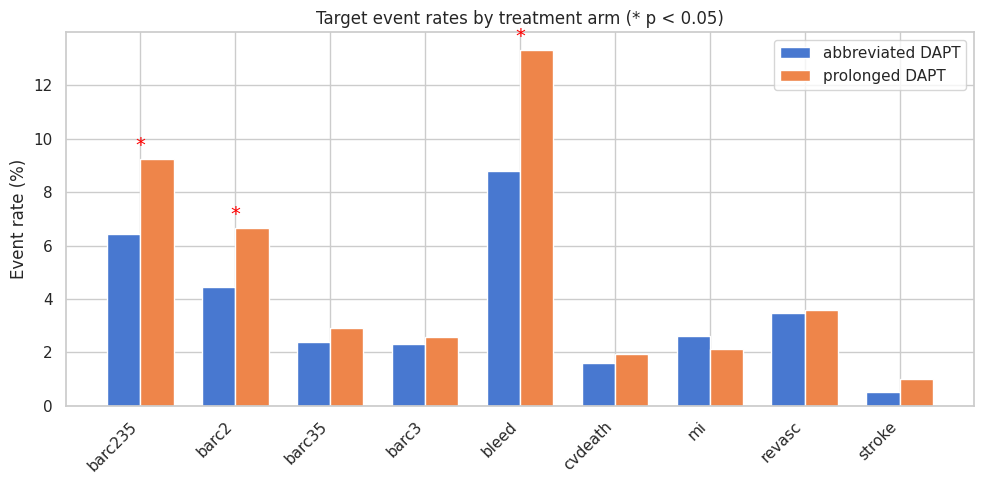

In [11]:
labels = [c.replace('cec_', '').replace('_335d', '') for c in rates_pivot.index]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, rates_pivot.iloc[:, 0] * 100, width, label=rates_pivot.columns[0])
ax.bar(x + width/2, rates_pivot.iloc[:, 1] * 100, width, label=rates_pivot.columns[1])

for i, p in enumerate(rates_pivot['p_value']):
    if p < 0.05:
        y = max(rates_pivot.iloc[i, 0], rates_pivot.iloc[i, 1]) * 100
        ax.text(x[i], y + 0.3, '*', ha='center', fontsize=14, color='red')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Event rate (%)')
ax.set_title('Target event rates by treatment arm (* p < 0.05)')
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** Bleeding-related composite endpoints (`cec_bleed_335d`, `cec_barc235_335d`, `cec_barc2_335d`) show significantly higher event rates in the prolonged-DAPT arm (p < 0.05), consistent with the trial hypothesis that a longer antiplatelet regimen increases bleeding risk. The ischemic endpoints (MI, stroke, CV death, revascularization) and the broader BARC 3/3-5 bleeding categories show no significant difference between arms at this sample size. This suggests `regimen` is an informative feature primarily for the higher-level bleeding targets.

# Target Spearmann Correlation

Since all nine targets are binary, we measure pairwise association using Cramér's V (derived from the chi-square statistic of a 2×2 contingency table) rather than a linear correlation coefficient. Values range from 0 (no association) to 1 (perfect association).

In [12]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = ss.chi2_contingency(ct)
    n = ct.values.sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2_corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2_corr / min(k_corr-1, r_corr-1)), chi2, p

cols = target_features.columns
results = []

for col1, col2 in combinations(cols, 2):
    x = target_features[col1].dropna()
    y = target_features[col2].dropna()
    idx = x.index.intersection(y.index)
    x, y = x[idx], y[idx]
    
    v, chi2, p = cramers_v(x, y)
    
    ct = pd.crosstab(x, y)
    phi = np.sqrt(chi2 / len(idx)) if ct.shape == (2, 2) else np.nan
    
    results.append({
        'feature_1': col1,
        'feature_2': col2,
        'chi2': round(chi2, 3),
        'p_value': round(p, 4),
        'phi': round(phi, 4) if not np.isnan(phi) else np.nan,
        'cramers_v': round(v, 4),
        'significant': p < 0.05
    })

results_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False)

The results are visualized as a symmetric heatmap (left) and a ranked bar chart of the strongest pairwise associations (right); asterisks/red bars indicate statistically significant associations.

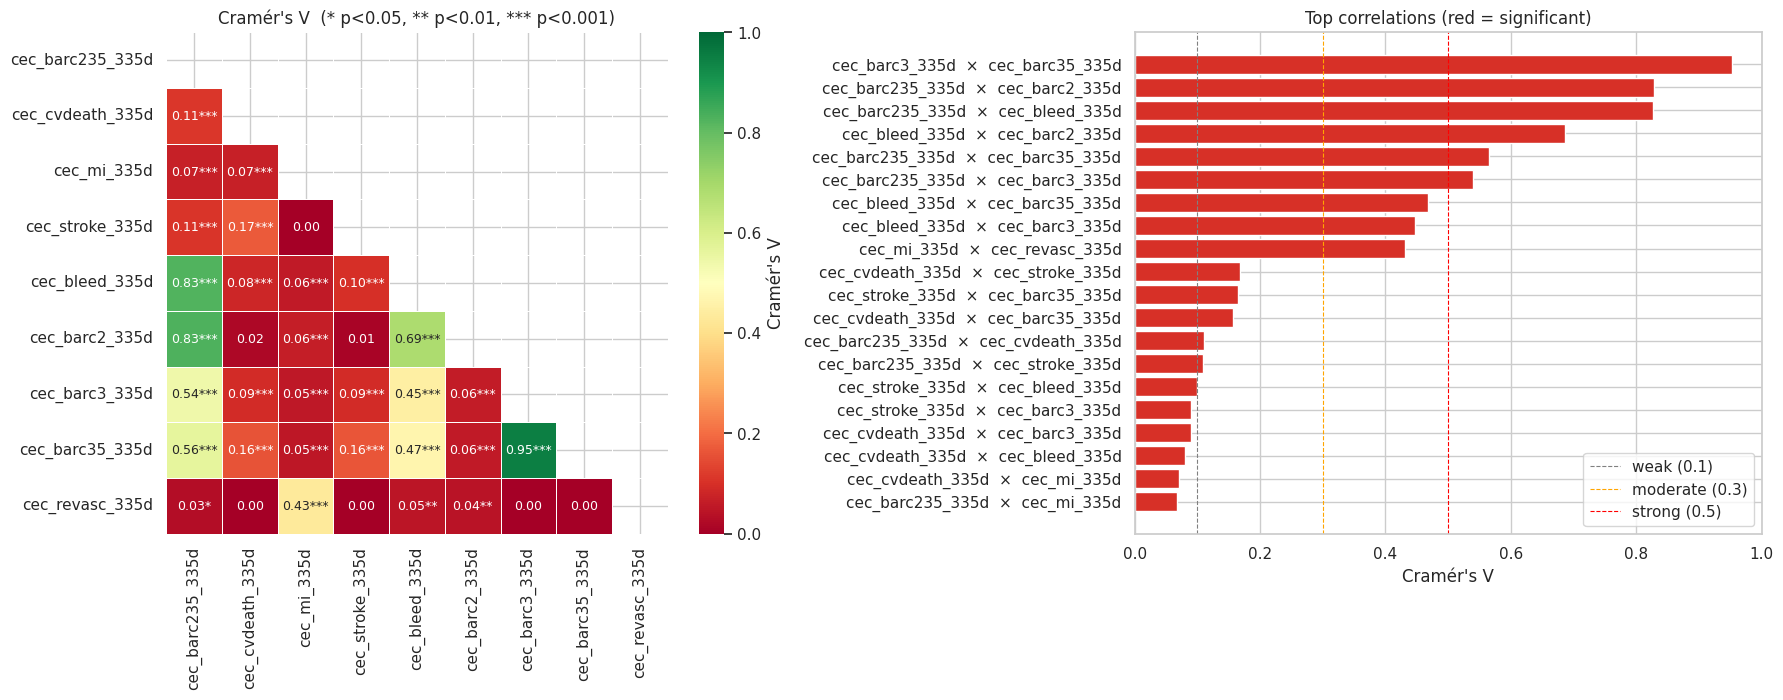

In [13]:
# Build symmetric matrix
matrix_v = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
matrix_p = pd.DataFrame(np.ones((len(cols), len(cols))), index=cols, columns=cols)

for _, row in results_df.iterrows():
    matrix_v.loc[row['feature_1'], row['feature_2']] = row['cramers_v']
    matrix_v.loc[row['feature_2'], row['feature_1']] = row['cramers_v']
    matrix_p.loc[row['feature_1'], row['feature_2']] = row['p_value']
    matrix_p.loc[row['feature_2'], row['feature_1']] = row['p_value']

# Significance mask (asterisks)
annot = matrix_v.copy().astype(str)
for i in cols:
    for j in cols:
        v = matrix_v.loc[i, j]
        p = matrix_p.loc[i, j]
        if i == j:
            annot.loc[i, j] = '1.00'
        else:
            stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            annot.loc[i, j] = f'{v:.2f}{stars}'

fig, axes = plt.subplots(1, 2, figsize=(18,7))

# --- Plot 1: Cramér's V heatmap ---
mask = np.triu(np.ones_like(matrix_v, dtype=bool))  # upper triangle
sns.heatmap(
    matrix_v, ax=axes[0],
    mask=mask,
    annot=annot, fmt='', annot_kws={'size': 9},
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'label': "Cramér's V"}
)
axes[0].set_title("Cramér's V  (* p<0.05, ** p<0.01, *** p<0.001)")
axes[0].tick_params(axis='x')

# --- Plot 2: ranked bar chart ---
top = results_df.sort_values('cramers_v', ascending=True).tail(20)
colors = ['#d73027' if p < 0.05 else '#91bfdb' for p in top['p_value']]
axes[1].barh(
    top['feature_1'] + '  ×  ' + top['feature_2'],
    top['cramers_v'],
    color=colors
)
axes[1].axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='weak (0.1)')
axes[1].axvline(0.3, color='orange', linestyle='--', linewidth=0.8, label='moderate (0.3)')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=0.8, label='strong (0.5)')
axes[1].set_xlabel("Cramér's V")
axes[1].set_title("Top correlations (red = significant)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature Correlation with Targets

To understand which predictors are most strongly associated with each clinical outcome, we classify every feature in `X` as **binary**, **categorical**, or **continuous**, and compute an appropriate association measure with each target: point-biserial correlation for continuous features, and Cramér's V for categorical/binary features.

In [14]:
def classify_col(series):
    n_unique = series.dropna().nunique()
    if n_unique == 2:
        return 'binary'
    elif pd.api.types.is_numeric_dtype(series) and n_unique > 10:
        return 'continuous'
    else:
        return 'categorical'

def corr_with_target(target_series, feature_series, ftype):
    idx = target_series.dropna().index.intersection(feature_series.dropna().index)
    t, f = target_series[idx], feature_series[idx]
    if len(idx) < 10:
        return np.nan, np.nan
    if ftype == 'continuous':
        r, p = pointbiserialr(t, f)
        return abs(r), p
    else:
        ct = pd.crosstab(t, f)
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            return np.nan, np.nan
        chi2, p, _, _ = chi2_contingency(ct)
        n = ct.values.sum()
        r, k = ct.shape
        v = np.sqrt(max(0, chi2/n - (k-1)*(r-1)/(n-1)) /
                    (min(k - (k-1)**2/(n-1), r - (r-1)**2/(n-1)) - 1))
        return v, p

For each target, we rank features by association strength and plot the top 15, colored by feature type and faded where the association is not statistically significant (p ≥ 0.05).

['cec_barc235_335d', 'cec_cvdeath_335d', 'cec_mi_335d', 'cec_stroke_335d', 'cec_bleed_335d', 'cec_barc2_335d', 'cec_barc3_335d', 'cec_barc35_335d', 'cec_revasc_335d']


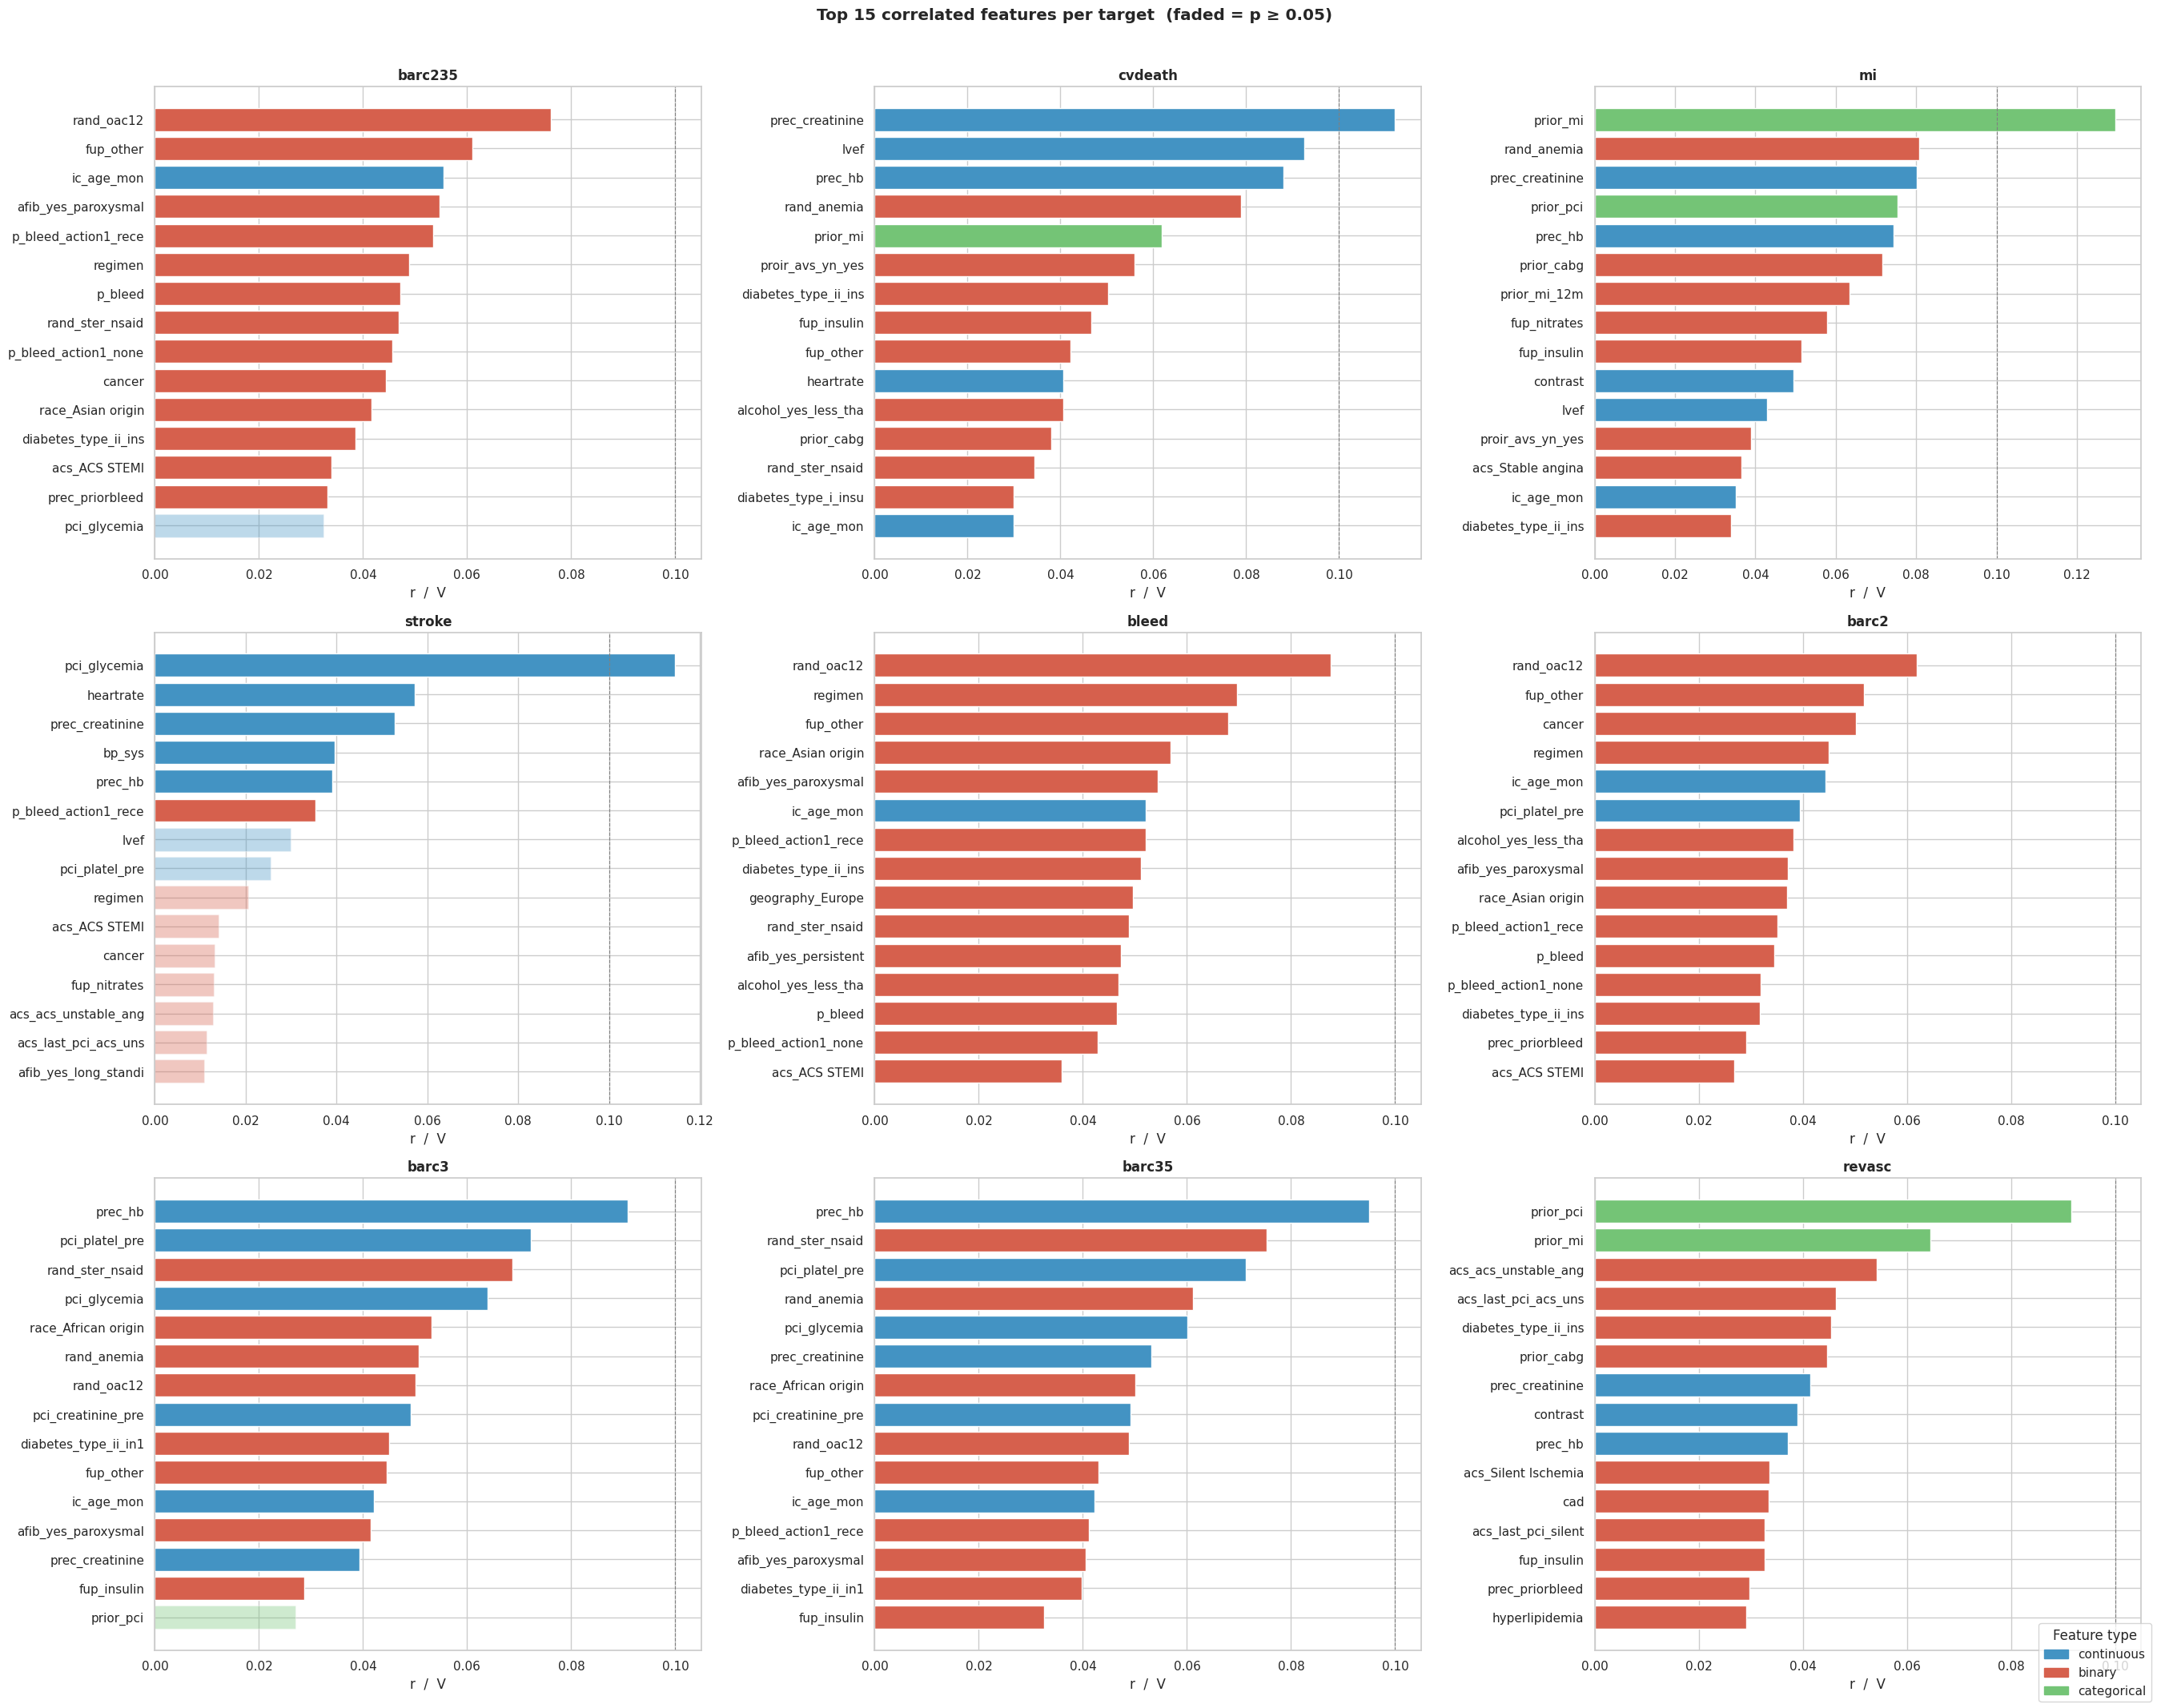

In [15]:
import math, textwrap

MAX_LABEL = 25

def truncate(s, n=MAX_LABEL):
    return s[:n-1] + '…' if len(s) > n else s

def clean_title(s):
    # adatta i replace ai nomi reali delle tue colonne
    return s.replace('cec_', '').replace('_335d', '')

TOP_X = 15
feature_cols = list(X.columns)
col_types = {c: classify_col(X[c]) for c in feature_cols}

target_cols = list(target_features.columns)
print(target_cols)

n = len(target_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 7 * nrows))
axes = axes.flatten()

color_map = {'continuous': '#4393c3', 'binary': '#d6604d', 'categorical': '#74c476'}

for i, target_col in enumerate(target_cols):
    ax = axes[i]
    records = []

    for col, ftype in col_types.items():
        v, p = corr_with_target(target_features[target_col], X[col], ftype)
        if not np.isnan(v):
            records.append({'feature': col, 'corr': v, 'p': p, 'type': ftype})

    res = (pd.DataFrame(records)
             .sort_values('corr', ascending=False)
             .head(TOP_X)
             .sort_values('corr'))

    res['label'] = res['feature'].apply(truncate)
    
    colors = [color_map[t] for t in res['type']]
    alphas = [1.0 if p < 0.05 else 0.35 for p in res['p']]

    bars = ax.barh(res['label'], res['corr'], color=colors)
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)

    ax.axvline(0.1, color='gray',   ls='--', lw=0.8)
    #ax.axvline(0.3, color='orange', ls='--', lw=0.8)
    #ax.axvline(0.5, color='red',    ls='--', lw=0.8)
    ax.set_title(clean_title(target_col), fontweight='bold')
    ax.set_xlabel('r  /  V')
    ax.tick_params(axis='y')

for j in range(len(target_cols), len(axes)):
    axes[j].set_visible(False)

patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
fig.legend(handles=patches, loc='lower right', title='Feature type')
fig.suptitle(f'Top {TOP_X} correlated features per target  (faded = p ≥ 0.05)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()